In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import os
os.makedirs("models", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")

##  Load & Explore Data

In [2]:
df = pd.read_csv("water_potability.csv")

In [3]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.shape

(3276, 10)

In [5]:
df.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

In [6]:
df.isnull().sum()*100/len(df)

ph                 14.987790
Hardness            0.000000
Solids              0.000000
Chloramines         0.000000
Sulfate            23.840049
Conductivity        0.000000
Organic_carbon      0.000000
Trihalomethanes     4.945055
Turbidity           0.000000
Potability          0.000000
dtype: float64

In [7]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

##  Exploratory Data Analysis (EDA)

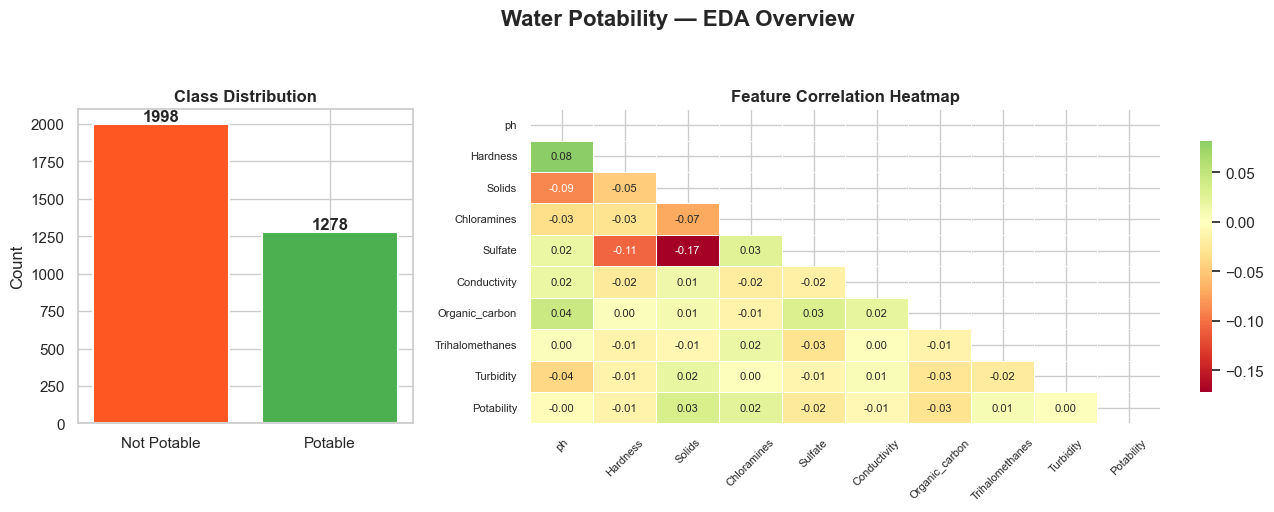

In [8]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Water Potability — EDA Overview", fontsize=16, fontweight='bold')
gs_fig = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Class distribution
ax0 = fig.add_subplot(gs_fig[0, 0])
counts = df['Potability'].value_counts()
bars = ax0.bar(['Not Potable', 'Potable'], counts.values,
               color=['#FF5722', '#4CAF50'], edgecolor='white', linewidth=1.5)
ax0.set_title("Class Distribution", fontweight='bold')
ax0.set_ylabel("Count")
for bar, val in zip(bars, counts.values):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontweight='bold')

# Correlation heatmap (using original features for now)
ax1 = fig.add_subplot(gs_fig[0, 1:])
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax1, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax1.set_title("Feature Correlation Heatmap", fontweight='bold')
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)



plt.tight_layout()
plt.show()

##  Data Cleaning

**Strategy:** Fill missing values using **median per class** (grouped by `Potability`).  
This is smarter than global median because potable and non-potable water have different distributions.  
Affected columns: `ph` (491 missing), `Sulfate` (781 missing), `Trihalomethanes` (162 missing).

In [9]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [10]:
# Fill missing values with median per Potability class
for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    df[col] = df.groupby('Potability')[col].transform(lambda x: x.fillna(x.median()))


In [11]:
# After fill missing Values 
df.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

In [12]:
df.shape

(3276, 10)

##  Feature Engineering(Extraction)

Creating 4 new meaningful features derived from domain knowledge (WHO water quality standards):

| New Feature | Formula | Justification |
|---|---|---|
| `ph_deviation` | `abs(ph - 7.0)` | pH far from neutral 7.0 → higher contamination risk (WHO: 6.5–8.5) |
| `mineral_load` | `(Hardness + Solids) / 2` | Combined mineral load gives overall hardness index |
| `chem_risk` | `Chloramines × Trihalomethanes / 100` | Interaction between two disinfection byproducts → chemical toxicity proxy |
| `turbidity_organic_ratio` | `Turbidity / (Organic_carbon + 1)` | High turbidity with low organic carbon is abnormal → contamination indicator |

In [13]:
# pH deviation from neutral (WHO safe range: 6.5 - 8.5)
df['ph_deviation'] = abs(df['ph'] - 7.0)

# Combined mineral load
df['mineral_load'] = (df['Hardness'] + df['Solids']) / 2

# Chemical risk score (disinfection byproducts interaction)
df['chem_risk'] = df['Chloramines'] * df['Trihalomethanes'] / 100

# Turbidity to organic carbon ratio
df['turbidity_organic_ratio'] = df['Turbidity'] / (df['Organic_carbon'] + 1)



In [14]:
print(f"\nNew features added:")
new_feats = ['ph_deviation', 'mineral_load', 'chem_risk', 'turbidity_organic_ratio']
print(df[new_feats].describe().round(3))


New features added:
       ph_deviation  mineral_load  chem_risk  turbidity_organic_ratio
count      3276.000      3276.000   3276.000                 3276.000
mean          1.057     11105.231      4.734                    0.274
std           1.024      4383.545      1.566                    0.092
min           0.000       282.124      0.055                    0.078
25%           0.216      7933.277      3.654                    0.213
50%           0.799     10572.886      4.661                    0.259
75%           1.595     13762.229      5.710                    0.320
max           7.000     30693.298     11.883                    1.310


In [15]:
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability,ph_deviation,mineral_load,chem_risk,turbidity_organic_ratio
0,7.035456,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0,0.035456,10498.104718,6.350525,0.260386
1,3.716080,129.422921,18630.057858,6.635246,333.389426,592.885359,15.180013,56.329076,4.500656,0,3.283920,9379.740389,3.737573,0.278161
2,8.099124,224.236259,19909.541732,9.275884,333.389426,418.606213,16.868637,66.420093,3.055934,0,1.099124,10066.888996,6.161050,0.171022
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0,1.316766,11116.395417,8.086869,0.238148
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0,2.092223,9080.043924,2.094781,0.324493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1,2.331898,23887.336669,4.779266,0.297818
3272,7.808856,193.553212,17329.802160,8.061362,331.838167,392.449580,19.903225,66.678214,2.798243,1,0.808856,8761.677686,5.375172,0.133867
3273,9.419510,175.762646,33155.578218,7.350233,331.838167,432.044783,11.039070,69.845400,3.298875,1,2.419510,16665.670432,5.133800,0.274014
3274,5.126763,230.603758,11983.869376,6.303357,331.838167,402.883113,11.168946,77.488213,4.708658,1,1.873237,6107.236567,4.884358,0.386941


In [16]:
df.shape

(3276, 14)

##  Feature Selection

**Decision:** Keep all 13 features (9 original + 4 engineered).

**Justification:**
- All original features relate directly to WHO water quality parameters — no column is irrelevant
- Engineered features add non-linear relationships not captured by raw values
- Correlation heatmap shows no extreme multicollinearity (no pair > 0.9)
- StandardScaler will handle different scales before modeling

In [17]:
feature_cols = [c for c in df.columns if c != 'Potability']
X = df[feature_cols]
y = df['Potability']

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f} (imbalanced — will use stratified split)") 

Features (13): ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'ph_deviation', 'mineral_load', 'chem_risk', 'turbidity_organic_ratio']

Target distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64

Class ratio: 1.56 (imbalanced — will use stratified split)


##  Train/Test Split & Feature Scaling

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)       # fit ONLY on train — prevent data leakage

joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(feature_cols, "models/feature_cols.pkl")

print(f"Train set : {X_train.shape} | Potability: {y_train.value_counts().to_dict()}")
print(f"Test set  : {X_test.shape}  | Potability: {y_test.value_counts().to_dict()}")
print(f"\nStandardScaler applied. Features are now zero-mean, unit-variance.")

Train set : (2620, 13) | Potability: {0: 1598, 1: 1022}
Test set  : (656, 13)  | Potability: {0: 400, 1: 256}

StandardScaler applied. Features are now zero-mean, unit-variance.


##  Phase 2 – Model Training with GridSearchCV

**4 Algorithms selected:**
1. **Logistic Regression** — linear baseline
2. **Decision Tree** — interpretable non-linear
3. **Random Forest** — ensemble, typically best performance
4. **SVM** — strong classifier for medium datasets

**Tuning:** 5-Fold Stratified Cross-Validation via `GridSearchCV`

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_config = {
    "Logistic Regression": {
        "estimator": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "solver": ["lbfgs", "liblinear"]
        }
    },
    "Decision Tree": {
        "estimator": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 7, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        }
    },
    "SVM": {
        "estimator": SVC(random_state=42, probability=True),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"]
        }
    }
}

results = {}
best_models = {}

for name, config in models_config.items():
    print(f"\n{'='*45}")
    print(f"  Training: {name}")
    print(f"{'='*45}")

    gs = GridSearchCV(
        config["estimator"],
        config["params"],
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train_sc, y_train)
    best_model = gs.best_estimator_
    best_models[name] = best_model

    y_pred = best_model.predict(X_test_sc)
    y_prob = best_model.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    

    results[name] = {
        "accuracy": acc, "precision": prec, "recall": rec,
        "f1": f1,
        "cm": cm,
        "best_params": gs.best_params_
    }

    print(f"  Best Params  : {gs.best_params_}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  Precision    : {prec:.4f}")
    print(f"  Recall       : {rec:.4f}")
    print(f"  F1 Score     : {f1:.4f}")
    joblib.dump(best_model, f"models/{name.replace(' ', '_')}.pkl")

joblib.dump(results, "models/results.pkl")


  Training: Logistic Regression
  Best Params  : {'C': 0.01, 'solver': 'lbfgs'}
  Accuracy     : 0.6098
  Precision    : 0.0000
  Recall       : 0.0000
  F1 Score     : 0.0000

  Training: Decision Tree
  Best Params  : {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 2}
  Accuracy     : 0.7561
  Precision    : 0.7791
  Recall       : 0.5234
  F1 Score     : 0.6262

  Training: Random Forest
  Best Params  : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
  Accuracy     : 0.8064
  Precision    : 0.8308
  Recall       : 0.6328
  F1 Score     : 0.7184

  Training: SVM
  Best Params  : {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
  Accuracy     : 0.6585
  Precision    : 0.6702
  Recall       : 0.2461
  F1 Score     : 0.3600


['models/results.pkl']

## 📋 Results Summary

In [20]:
summary = pd.DataFrame({
    name: {k: round(res[k], 4) for k in ['accuracy', 'precision', 'recall', 'f1']}
    for name, res in results.items()
}).T

summary.columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
summary = summary.sort_values('F1 Score', ascending=False)
summary.style.background_gradient(cmap='RdYlGn', axis=0)

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.806400,0.830800,0.632800,0.718400
Decision Tree,0.756100,0.779100,0.523400,0.626200
SVM,0.658500,0.670200,0.246100,0.360000
Logistic Regression,0.609800,0.000000,0.000000,0.000000


### Confusion Matrices

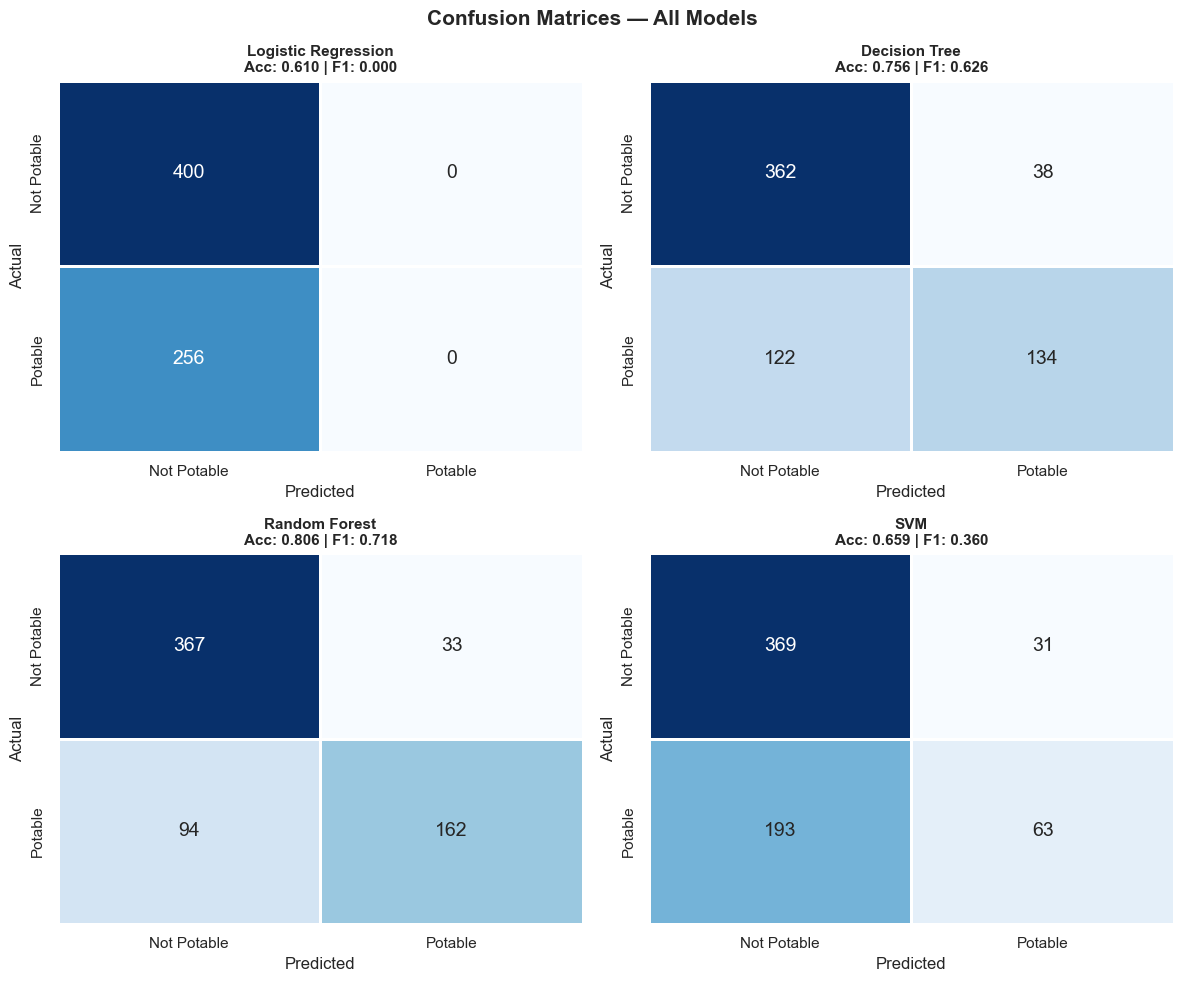

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                cmap='Blues', linewidths=1,
                xticklabels=['Not Potable', 'Potable'],
                yticklabels=['Not Potable', 'Potable'],
                cbar=False, annot_kws={'size': 14})
    axes[idx].set_title(
        f"{name}\nAcc: {res['accuracy']:.3f} | F1: {res['f1']:.3f}",
        fontweight='bold', fontsize=11
    )
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Model Performance Comparison

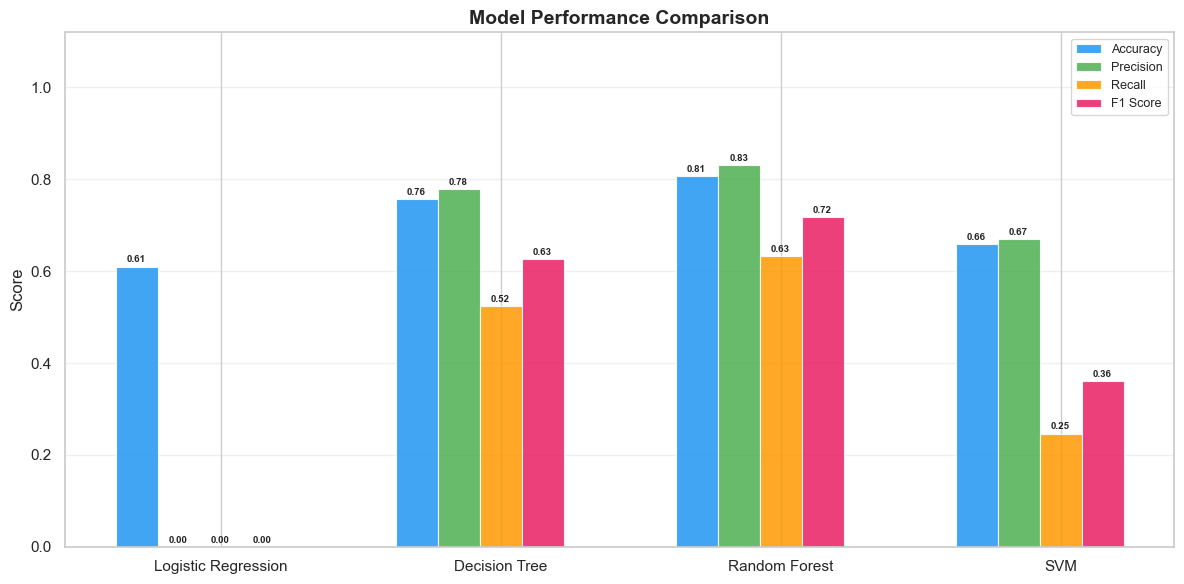

In [22]:
metrics_df = pd.DataFrame({
    name: {k: res[k] for k in ['accuracy', 'precision', 'recall', 'f1']}
    for name, res in results.items()
}).T

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_df))
width = 0.15
metric_names  = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, (metric, label, color) in enumerate(zip(metric_names, metric_labels, metric_colors)):
    bars = ax.bar(x + i * width, metrics_df[metric], width,
                  label=label, color=color, edgecolor='white', linewidth=0.8, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.2f}", ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest — Best Model)

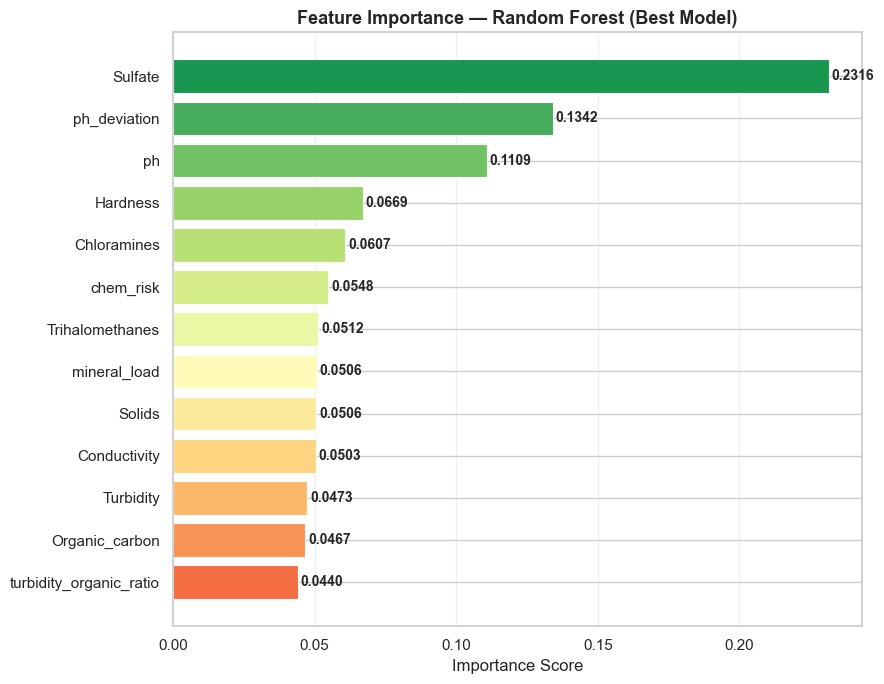

In [23]:
rf_model = best_models["Random Forest"]
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'],
               color=colors_fi, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=10, fontweight='bold')
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Feature Importance — Random Forest (Best Model)", fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()